# American Sign Language (ASL) Detection

## 1. Import Libraries

In [1]:
# Basic libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Data preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# CNN model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

2026-07-01 16:28:40.991420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782923321.014516     169 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782923321.021988     169 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782923321.040406     169 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782923321.040427     169 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782923321.040429     169 computation_placer.cc:177] computation placer alr

## 2. Load Dataset 

In [2]:
# Defining dataset paths
train_dir = '/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train'
test_dir = '/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test/asl_alphabet_test'

print("Training Dataset Path:", train_dir)
print("Testing Dataset Path :", test_dir)

Training Dataset Path: /kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Testing Dataset Path : /kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test/asl_alphabet_test


## 3. Dataset Overview

In [3]:
# Class names from training dataset
classes = sorted(os.listdir(train_dir))

print("Total Number of Classes:", len(classes))
print("Classes in the dataset:")
print(classes)

Total Number of Classes: 29
Classes in the dataset:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [4]:
# Total number of training images
total_train_images = 0

for cls in classes:
    total_train_images += len(os.listdir(os.path.join(train_dir, cls)))

print("Total Training Images:", total_train_images)

Total Training Images: 87000


In [5]:
# Total number of testing images
total_test_images = len(os.listdir(test_dir))

print("Total Testing Images:", total_test_images)

Total Testing Images: 28


In [6]:
# Displaying number of images in each class
for cls in classes:
    image_count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {image_count} images")

A: 3000 images
B: 3000 images
C: 3000 images
D: 3000 images
E: 3000 images
F: 3000 images
G: 3000 images
H: 3000 images
I: 3000 images
J: 3000 images
K: 3000 images
L: 3000 images
M: 3000 images
N: 3000 images
O: 3000 images
P: 3000 images
Q: 3000 images
R: 3000 images
S: 3000 images
T: 3000 images
U: 3000 images
V: 3000 images
W: 3000 images
X: 3000 images
Y: 3000 images
Z: 3000 images
del: 3000 images
nothing: 3000 images
space: 3000 images


## 4. Data Preprocessing

In [7]:
# Creating image data generator 
datagen = ImageDataGenerator(rescale=1./255, # Normalises pixel values to range [0,1]
                             validation_split=0.2) # Reserve 20% of training data for validation
                            

In [8]:
# Creating training dataset
train_generator = datagen.flow_from_directory(train_dir,target_size=(64,64),batch_size=32,              
    class_mode='categorical',subset='training')

Found 69600 images belonging to 29 classes.


In [9]:
# Creating validation dataset
validation_generator = datagen.flow_from_directory(train_dir,target_size=(64, 64),batch_size=32,
    class_mode='categorical',subset='validation')        # Using remaining 20% for validation

Found 17400 images belonging to 29 classes.


In [10]:
# Displaying dataset information
print("Training Samples :", train_generator.samples)
print("Validation Samples:", validation_generator.samples)
print("Number of Classes :", train_generator.num_classes)

Training Samples : 69600
Validation Samples: 17400
Number of Classes : 29


## 5. Image Visualization

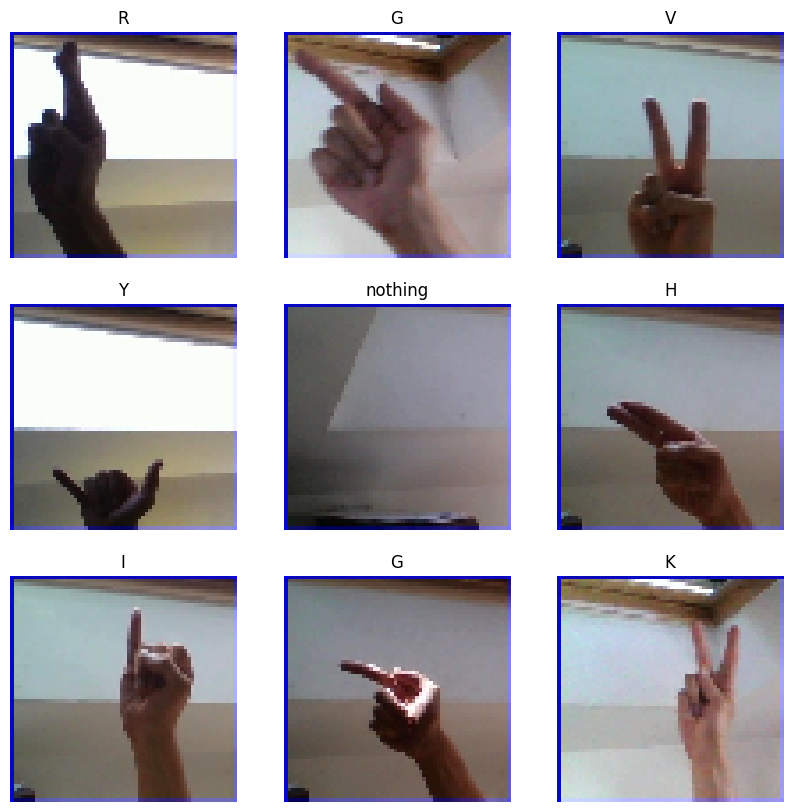

In [11]:
# Displaing sample images from the dataset
images, labels = next(train_generator)
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis('off')

plt.show()

## 6. CNN Model Building

In [12]:
# Building CNN model
model = Sequential([Input(shape=(64,64,3)),
                    Conv2D(32, (3,3), activation='relu'),MaxPooling2D(2,2),
                    Conv2D(64, (3,3), activation='relu'),MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),MaxPooling2D(2,2),
                    Flatten(),Dense(128, activation='relu'),
                    Dropout(0.5),Dense(29, activation='softmax')])

I0000 00:00:1782923396.471335     169 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782923396.476804     169 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
# Compiling CNN model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [14]:
# Displaying model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,941 (2.62 MB)

 Trainable params: 686,941 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Training

In [15]:
history = model.fit(train_generator,validation_data=validation_generator,epochs=10)

Epoch 1/10


I0000 00:00:1782923407.801628     248 service.cc:152] XLA service 0x7eabd4004d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782923407.801677     248 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782923407.801684     248 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782923408.222484     248 cuda_dnn.cc:529] Loaded cuDNN version 91002


   3/2175 ━━━━━━━━━━━━━━━━━━━━ 2:58 82ms/step - accuracy: 0.0122 - loss: 3.4093     

I0000 00:00:1782923411.596347     248 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 470s 214ms/step - accuracy: 0.6115 - loss: 1.2384 - val_accuracy: 0.7225 - val_loss: 0.9363
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 143s 66ms/step - accuracy: 0.8938 - loss: 0.3035 - val_accuracy: 0.7731 - val_loss: 0.8671
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 104s 48ms/step - accuracy: 0.9429 - loss: 0.1645 - val_accuracy: 0.8050 - val_loss: 0.8610
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9588 - loss: 0.1182 - val_accuracy: 0.8199 - val_loss: 0.7775
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9701 - loss: 0.0877 - val_accuracy: 0.8029 - val_loss: 0.9296
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - accuracy: 0.9759 - loss: 0.0708 - val_accuracy: 0.8189 - val_loss: 0.9568
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - accuracy: 0.9789 - loss: 0.0630 - val_accuracy: 0.8250 - val_loss: 0.8923
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 105s 48ms/step - accuracy: 0.9828 - l

## 8. Model Evaluation

In [16]:
# Evaluating model performance on validation dataset
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

544/544 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8219 - loss: 1.0240
Validation Loss: 1.023950219154358
Validation Accuracy: 0.8218965530395508


## 9. Training History Visualization

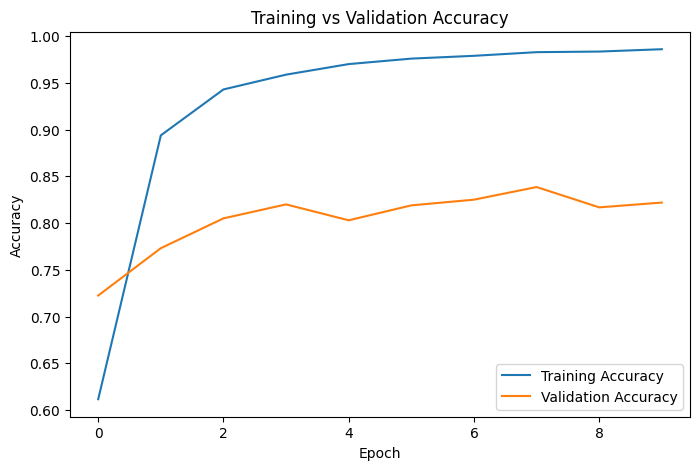

In [17]:
# Plot training and validation accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

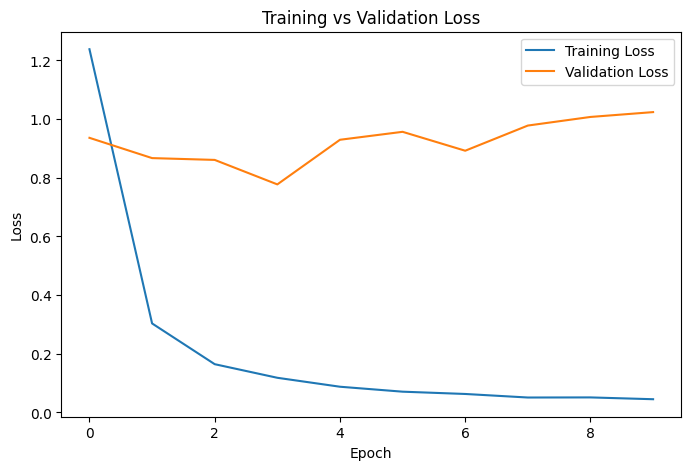

In [18]:
# Plot training and validation loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 10. Prediction

In [19]:
img_path = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test/asl_alphabet_test/A_test.jpg"

img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_label = list(train_generator.class_indices.keys())[np.argmax(prediction)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step


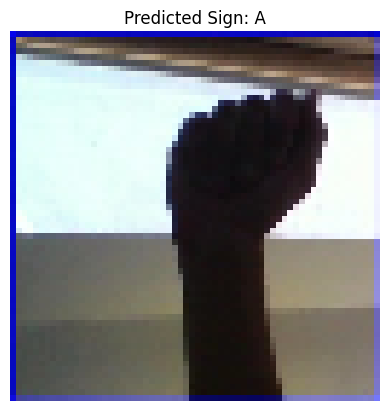

In [20]:
plt.imshow(img)
plt.title(f"Predicted Sign: {predicted_label}")
plt.axis('off')
plt.show()

In [22]:
model.save("asl_model.keras")

In [23]:
import os
print(os.listdir())

['asl_model.keras', '.virtual_documents']
